# Init

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from keras import layers, models, optimizers
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, roc_auc_score
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
import random

In [2]:
# Esta linea de código es para evitar que salten warnings 
tf.config.optimizer.set_experimental_options({"remapping": False})
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

Configuramos Tensorflow para que detecte la GPU para ejecutar los entrenamientos de las CNN ya que son computacionalmente pesados

In [3]:
seed = 42
tf.keras.utils.set_random_seed(seed)
np.random.seed(seed)
random.seed(seed)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as error:
        print("No se pudo activar memory growth:", error)

training_device = "/GPU:0" if gpus else "/CPU:0"
print("TensorFlow:", tf.__version__)
print("GPUs:", gpus)
print("Training device:", training_device)

TensorFlow: 2.14.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Training device: /GPU:0


# Lectura del Dataset

In [4]:
X_train = h5py.File('camelyonpatch_level_2_split_train_x.h5', 'r')
y_train = h5py.File('camelyonpatch_level_2_split_train_y.h5', 'r')

In [15]:
X_val = h5py.File('camelyonpatch_level_2_split_valid_x.h5', 'r')
y_val = h5py.File('camelyonpatch_level_2_split_valid_y.h5', 'r')

In [14]:
X_test = h5py.File('camelyonpatch_level_2_split_test_x.h5', 'r')
y_test = h5py.File('camelyonpatch_level_2_split_test_y.h5', 'r')

In [4]:
num_img = X_train['x'].shape[0]
pix1 = X_train['x'].shape[1]
pix2 = X_train['x'].shape[2]
rgb = X_train['x'].shape[3]
print(f"Número de imágenes de train: {num_img}")
print(f"Tamaño de las imágenes en píxeles: {pix1} x {pix2}")
print(f"Número de canales para la colorimetría: {rgb}")


Número de imágenes de train: 262144
Tamaño de las imágenes en píxeles: 96 x 96
Número de canales para la colorimetría: 3


# Exploratory Data Analysis and Data transformation

In [ ]:
# Vemos una imagen de ejemplo
X_train['x'][0]

array([[[226, 209, 225],
        [224, 210, 225],
        [223, 211, 223],
        ...,
        [218, 178, 230],
        [214, 182, 221],
        [188, 161, 192]],

       [[223, 209, 224],
        [222, 210, 224],
        [221, 211, 222],
        ...,
        [127,  87, 150],
        [159, 126, 181],
        [204, 176, 225]],

       [[222, 210, 224],
        [221, 210, 224],
        [219, 211, 222],
        ...,
        [ 77,  38, 117],
        [ 42,   8,  84],
        [137, 107, 179]],

       ...,

       [[123,  81, 165],
        [128,  90, 173],
        [126,  91, 173],
        ...,
        [203, 135, 210],
        [226, 155, 223],
        [202, 130, 194]],

       [[ 90,  52, 139],
        [ 90,  56, 142],
        [ 79,  45, 131],
        ...,
        [216, 152, 230],
        [179, 113, 185],
        [217, 152, 220]],

       [[ 85,  51, 138],
        [101,  68, 155],
        [ 91,  59, 144],
        ...,
        [200, 136, 220],
        [204, 142, 217],
        [192, 130, 203]]

In [6]:
print(f"Tipo de los píxeles de las imágenes: {X_train['x'][0][:].dtype}")

Tipo de los píxeles de las imágenes: uint8


## Balanceo de clases

In [ ]:
# ===== EDA =====
# 1. Análisis y exploración visual

# 1.1 Cada imagen es una matriz de tamaño 96 x 96 x 3
# Validamos el contenido de cada elemento para confirmar que es la intensidad lumínica de los píxeles
valor_max_pix = np.max(X_train['x'][0])
valor_min_pix = np.min(X_train['x'][0])
print(f"Valor máximo que toma un píxel:{valor_max_pix}")
print(f"Valor mínimo que toma un píxel:{valor_min_pix}")
print(f"Shape de y_train: {y_train['y'].shape}")


Valor máximo que toma un píxel:255
Valor mínimo que toma un píxel:0
Shape de y_train: (262144, 1, 1, 1)


In [ ]:
# 1.2 Comprobamos si el DF está balanceado por clase para la etiqueta a predecir (ausencia - 0 o presencia - 1 de cáncer)
etiquetas = y_train['y'][:]
clases, conteos = np.unique(etiquetas, return_counts=True)
print(f"Clases posibles del label: {clases}")
print(f"Number of rows for the previous classes: {conteos}")

Clases posibles del label: [0 1]
Number of rows for the previous classes: [131072 131072]


In [ ]:
# 1.3 Exploramos tambíen los datasets de validación y test
print(f"Tamaño de X_val: {X_val['x'].shape}")
print(f"Tamaño de y_val: {y_val['y'].shape}")

# Y observamos que el dataset de validación también está balanceado
etiquetas_val = y_val['y'][:]
clases_val, conteos_val = np.unique(etiquetas_val, return_counts=True)
print(f"Clases posibles del label: {clases_val}")
print(f"Number of rows for the previous classes: {conteos_val}")


Tamaño de X_val: (32768, 96, 96, 3)
Tamaño de y_val: (32768, 1, 1, 1)
Clases posibles del label: [0 1]
Number of rows for the previous classes: [16399 16369]


In [ ]:
 # Se realiza la misma exploración para el dataset de test. Este dataset está casi perfectamente balanceado para la clase objetivo. Solo difiere
# en algunos registros más para la clase 0 pero en proporción al total de filas se puede considerar que está balanceado. También puede ser una señal que 
# refleja un subset "real" de datos futuros no exactamente balanceados, para los que el modelo será aplicado.

print(f"Tamaño  de X_test: {X_test['x'].shape}")
print(f"Tamaño de y_test: {y_test['y'].shape}")

etiquetas_test = y_test['y'][:]
clases_test, conteos_test = np.unique(etiquetas_test, return_counts=True)
print(f"Clases posibles del label: {clases_test}")
print(f"Number of rows for the previous classes: {conteos_test}")

Tamaño  de X_test: (32768, 96, 96, 3)
Tamaño de y_test: (32768, 1, 1, 1)
Clases posibles del label: [0 1]
Number of rows for the previous classes: [16391 16377]


Tanto el dataset de train, como el de validación y test están balanceados por clase 0 y 1

Etiqueta para la imagen 0 de train: [[[0]]]


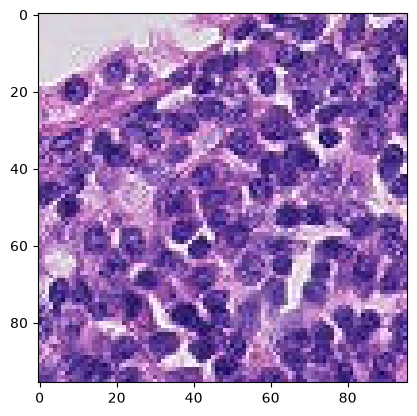

In [ ]:
# (EDA) - Visualizamos algunas imágenes
# La primera imagen corresponde a tejido sano
print(f"Etiqueta para la imagen 0 de train: {y_train['y'][0]}")
plt.imshow(X_train['x'][0]);

In [ ]:
# Observamos que aunque la etiqueta solo puede valer 0 o 1, cada valor viene almacenado en una matriz de 3 dimensiones que solo contiene un elemento
y_train['y'].shape

(262144, 1, 1, 1)

Etiqueta para la imagen 1 de train:[[[1]]]


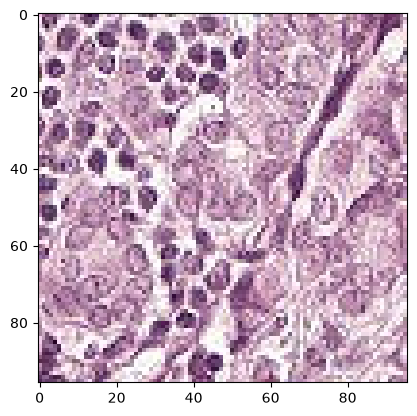

In [ ]:
# Visualizamos una imagen con tejido cancerígeno
# Hay formas irregulares de células en el centro y esquina inferior izquierda.
print(f"Etiqueta para la imagen 1 de train:{y_train['y'][1]}")
plt.imshow(X_train['x'][1]);

In [14]:
X_train['x'][1]

array([[[243, 196, 232],
        [159, 111, 149],
        [117,  69, 109],
        ...,
        [116,  70, 107],
        [149, 114, 144],
        [255, 244, 255]],

       [[255, 232, 255],
        [ 82,  38,  71],
        [167, 126, 160],
        ...,
        [117,  73, 109],
        [172, 138, 165],
        [181, 153, 175]],

       [[255, 227, 251],
        [ 85,  52,  79],
        [105,  71,  98],
        ...,
        [ 98,  57,  91],
        [151, 117, 142],
        [233, 204, 224]],

       ...,

       [[123,  82, 122],
        [ 67,  26,  66],
        [ 80,  39,  79],
        ...,
        [255, 240, 255],
        [255, 240, 255],
        [216, 172, 197]],

       [[ 96,  58,  99],
        [137,  99, 140],
        [144, 106, 147],
        ...,
        [175, 140, 164],
        [176, 136, 162],
        [208, 165, 193]],

       [[ 79,  40,  84],
        [117,  78, 122],
        [ 99,  60, 104],
        ...,
        [172, 138, 163],
        [157, 118, 147],
        [174, 131, 161]]

Etiqueta para la imagen 2 de train:[[[1]]]


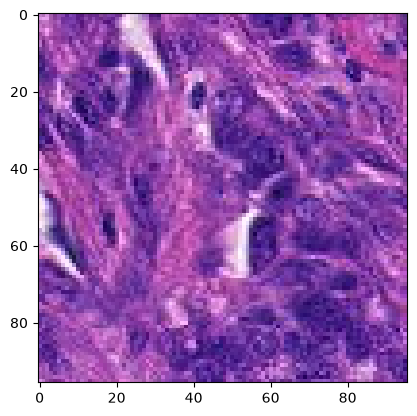

In [ ]:
# Esta es otra imagen con tejido maligno pero el brillo de los píxeles (el tono de rosa) varía respecto a la imagen anterior también para la clase 1
# El brillo en los canales RGB debe no ser similar de unas imágenes a otras de la misma clase (tiene sentido ya que las muestras pueden haber sido
# tomadas en diferentes condiciones)
print(f"Etiqueta para la imagen 2 de train:{y_train['y'][2]}")
plt.imshow(X_train['x'][2]);

Etiqueta para la imagen 3 de train:[[[1]]]


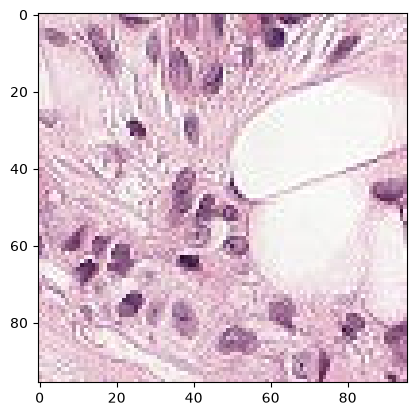

In [16]:
print(f"Etiqueta para la imagen 3 de train:{y_train['y'][3]}")
plt.imshow(X_train['x'][3]);

In [17]:
total_images = X_train['x'].shape[0]
total_images * X_train['x'].shape[1] * X_train['x'].shape[2]

2415919104

In [ ]:
# Como los datos cargados vienen en formato HDF5, para aplicar más facilmente el proceso de transformación de features lo vamos a almacenar en un dataset de 
# Tensorflow posteriormente
X_train['x']

<HDF5 dataset "x": shape (262144, 96, 96, 3), type "|u1">

## Valores faltantes

In [19]:
num_nulos_train = np.isnan(X_train['x']).sum()
num_nulos_val = np.isnan(X_val['x']).sum()
num_nulos_test = np.isnan(X_test['x']).sum()

print(f"Numero de nulos en el DF de train: {num_nulos_train}")
print(f"Numero de nulos en el DF de validacion: {num_nulos_val}")
print(f"Numero de nulos en el DF de test: {num_nulos_test}")

Numero de nulos en el DF de train: 0
Numero de nulos en el DF de validacion: 0
Numero de nulos en el DF de test: 0


In [20]:
num_nulos_train_y = np.isnan(y_train['y']).sum()
num_nulos_val_y = np.isnan(y_val['y']).sum()
num_nulos_test_y = np.isnan(y_test['y']).sum()

print(f"Numero de nulos en las etiquetas de train: {num_nulos_train_y}")
print(f"Numero de nulos en las etiquetas de validacion: {num_nulos_val_y}")
print(f"Numero de nulos en las etiquetas de test: {num_nulos_test_y}")

Numero de nulos en las etiquetas de train: 0
Numero de nulos en las etiquetas de validacion: 0
Numero de nulos en las etiquetas de test: 0


In [16]:
# Esto es un TensorSliceDataset
dataset_train = tf.data.Dataset.from_tensor_slices((X_train['x'], y_train['y']))
dataset_val = tf.data.Dataset.from_tensor_slices((X_val['x'], y_val['y']))
dataset_test = tf.data.Dataset.from_tensor_slices((X_test['x'], y_test['y']))

# Vamos a ver el formato para el dataset de train por ejemplo
dataset_train

<_TensorSliceDataset element_spec=(TensorSpec(shape=(96, 96, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(1, 1, 1), dtype=tf.uint8, name=None))>

In [ ]:
# Comprobamos que tenemos la GPU disponible
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Pre-procesamiento de imágenes

In [11]:
def image_preprocessing(img, label):
    """
    Dad una imagen de ejemplo y su etiqueta, escalamos los valores de los píxeles para que se encuenten en el rango [0, 1] 
    y aplanamos las etiquetas para que no sea una matriz como veíamos anteriormente
    Input:
        img = matriz numérica que representa la imagen
        label = matriz numérica que representa la etiqueta de clase para dicha imagen
    Output:
        imagen y etiqueta transformadas
    """
    img_to_float_scaled = tf.cast(img, tf.float32) / 255.0
    label_flatten = tf.squeeze(label)

    return img_to_float_scaled, label_flatten

In [17]:
dataset_train_processed = dataset_train.map(image_preprocessing, num_parallel_calls=tf.data.AUTOTUNE)

In [18]:
dataset_val_processed = dataset_val.map(image_preprocessing, num_parallel_calls=tf.data.AUTOTUNE)

In [19]:
dataset_test_processed = dataset_test.map(image_preprocessing, num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
# Esta es la forma en que extraemos las imágenes con Tensorflow
next(iter(dataset_train_processed.take(1)))

(<tf.Tensor: shape=(96, 96, 3), dtype=float32, numpy=
 array([[[0.8862745 , 0.81960785, 0.88235295],
         [0.8784314 , 0.8235294 , 0.88235295],
         [0.8745098 , 0.827451  , 0.8745098 ],
         ...,
         [0.85490197, 0.69803923, 0.9019608 ],
         [0.8392157 , 0.7137255 , 0.8666667 ],
         [0.7372549 , 0.6313726 , 0.7529412 ]],
 
        [[0.8745098 , 0.81960785, 0.8784314 ],
         [0.87058824, 0.8235294 , 0.8784314 ],
         [0.8666667 , 0.827451  , 0.87058824],
         ...,
         [0.49803922, 0.34117648, 0.5882353 ],
         [0.62352943, 0.49411765, 0.70980394],
         [0.8       , 0.6901961 , 0.88235295]],
 
        [[0.87058824, 0.8235294 , 0.8784314 ],
         [0.8666667 , 0.8235294 , 0.8784314 ],
         [0.85882354, 0.827451  , 0.87058824],
         ...,
         [0.3019608 , 0.14901961, 0.45882353],
         [0.16470589, 0.03137255, 0.32941177],
         [0.5372549 , 0.41960785, 0.7019608 ]],
 
        ...,
 
        [[0.48235294, 0.31764707, 

In [ ]:
#Especificaciones de las imágenes y sus etiquetas
dataset_train_processed.element_spec

(TensorSpec(shape=(96, 96, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(), dtype=tf.uint8, name=None))

## Extracción de estadísticos

In [ ]:
# Separamos las imágenes por clases para sacar los estadísticos de forma independiente
def is_healthy(img, label):
    return label == 0

def is_tumor(img, label):
    return label == 1

dataset_class_0 = dataset_train_processed.filter(is_healthy)
dataset_class_1 = dataset_train_processed.filter(is_tumor)

In [21]:
# Extracción de estadísticos por clase

def get_statistics(dataset):
    BATCH_SIZE = 1024
    dataset_train_batches = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    sum_RGB = tf.zeros([3], dtype=tf.float32)
    sum_sqr_RGB = tf.zeros([3], dtype=tf.float32)
    total_pixels = 0.0

    for batch_images, _ in dataset_train_batches:
        #It joins like all pixels from all images (0), rows(1) and columns (2) keeping dimension 3 (RGB channels)
        sum_RGB += tf.reduce_sum(batch_images, axis=(0,1,2))
        sum_sqr_RGB += tf.reduce_sum(tf.square(batch_images), axis=(0,1,2))

        current_num_img = tf.cast(tf.shape(batch_images)[0], tf.float32)
        rows = tf.cast(tf.shape(batch_images)[1], tf.float32)
        columns = tf.cast(tf.shape(batch_images)[2], tf.float32)
        total_pixels += current_num_img * rows * columns

    mean_by_RGB = (sum_RGB / total_pixels).numpy()
    var_by_RGB = (sum_sqr_RGB / total_pixels ) - tf.square(mean_by_RGB)
    std_RGB = tf.sqrt(var_by_RGB).numpy()
    return mean_by_RGB, var_by_RGB, std_RGB

In [22]:
mean_by_RGB, var_by_RGB, std_RGB = get_statistics(dataset_train_processed)

In [29]:
# The means for red and green channels are higher than for blue, caused by the H&E process of coloring the tissues
print(f"Media de los canales Red, Green, Blue: {mean_by_RGB}")
print(f"Desviacion estándar de los canales Red, Green, Blue: {std_RGB}")


Media de los canales Red, Green, Blue: [0.70075595 0.5383579  0.6916206 ]
Desviacion estándar de los canales Red, Green, Blue: [0.23497802 0.27740887 0.2128949 ]


In [33]:
mean_by_RGB_0, var_by_RGB_0, std_RGB_0 = get_statistics(dataset_class_0)
mean_by_RGB_1, var_by_RGB_1, std_RGB_1 = get_statistics(dataset_class_1)

[Text(0, 0, 'Rojo'), Text(1, 0, 'Verde'), Text(2, 0, 'Azul')]

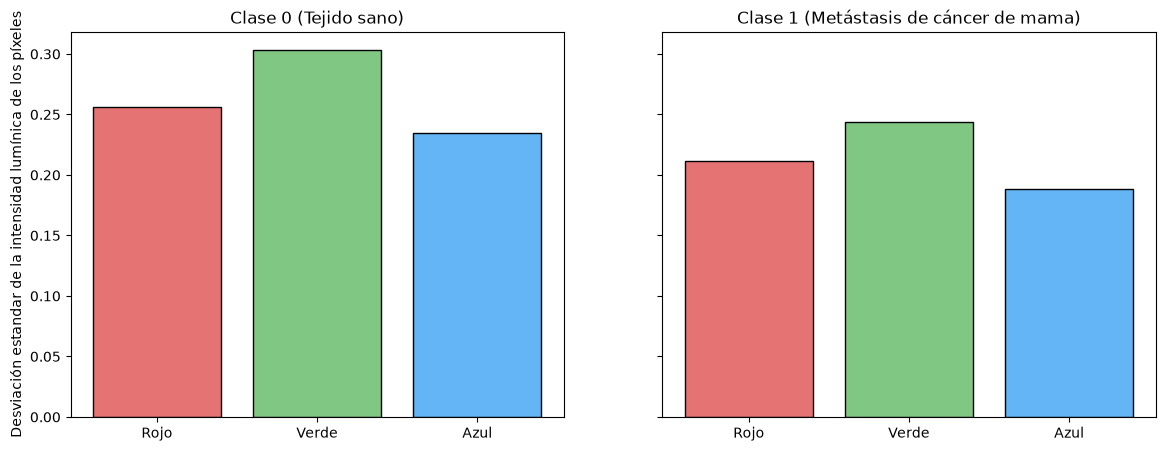

In [ ]:
# Se observa en las imágenes de la clase maligna, que el canal Rojo y verde tienen menos variación de intensidad lumínica  comparado con el canal Azul. Sin embargo,
# para la clase 0 el canal verde tiene mayor variacón de intensidades (según la desviación estándar).Esto puede impactar en las redes neuronales ya que esta diferencia entre canales de color son
# caracteristicas que podrían permitir separar las clases pero no son útiles porque están causadas por la técnica de toma de muestras y condiciones del entorno que pueden variar, no por la malignidad
# del tejido en sí.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
num_c = np.arange(3)
colors_rgb = ['#E57373', '#81C784', '#64B5F6']
ax1.bar(num_c, std_RGB_0, color=colors_rgb, edgecolor='black')
ax1.set_title("Clase 0 (Tejido sano)")
ax1.set_ylabel("Desviación estandar de la intensidad lumínica de los píxeles")
ax1.set_xticks(num_c)
ax1.set_xticklabels(["Rojo", "Verde", "Azul"])

ax2.bar(num_c, std_RGB_1, color=colors_rgb, edgecolor='black')
ax2.set_title("Clase 1 (Metástasis de cáncer de mama)")
ax2.set_xticks(num_c)
ax2.set_xticklabels(["Rojo", "Verde", "Azul"])


In [24]:
# Sacamos las 3 dimensiones de una imagen para usarlas a continuación
n_rows_per_img = X_train['x'].shape[1]
n_columns_per_img = X_train['x'].shape[2]
n_channels_per_img = X_train['x'].shape[3]

# FIRST CNN without Data Augmentation

In [ ]:
# Con las medias y las desviaciones estándar extraidas anteriormente vamos a normalizar las imágenes en la primera capa de la CNN
normalization_layer = layers.Normalization(
    mean=mean_by_RGB,
    variance=var_by_RGB,
    input_shape=(n_rows_per_img, n_columns_per_img, n_channels_per_img)
)

In [ ]:
# Configuración de la red

cnn = models.Sequential([
    layers.Input(shape=(n_rows_per_img,n_columns_per_img,n_channels_per_img)),
    normalization_layer,

    layers.Conv2D(35, (2,2), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Conv2D(32, (3,3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(65, (3,3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(65, (3,3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),
    
    layers.Conv2D(128, (3,3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.3),

    #Red neuronal para la clasificación
    layers.Flatten(),
    layers.Dense(512, activation="relu",kernel_initializer="random_normal"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

In [28]:
cnn.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization (Normalizati  (None, 96, 96, 3)         0         
 on)                                                             
                                                                 
 conv2d_6 (Conv2D)           (None, 96, 96, 35)        455       
                                                                 
 batch_normalization_7 (Bat  (None, 96, 96, 35)        140       
 chNormalization)                                                
                                                                 
 dropout_7 (Dropout)         (None, 96, 96, 35)        0         
                                                                 
 conv2d_7 (Conv2D)           (None, 96, 96, 32)        10112     
                                                                 
 batch_normalization_8 (Bat  (None, 96, 96, 32)       

## Entrenamiento

In [20]:
### Entrenamiento CNN1 en GPU si esta disponible
batch_size_cnn1 = 128

dataset_train_batch = (
    dataset_train_processed
    .shuffle(5000, seed=seed, reshuffle_each_iteration=True)
    .batch(batch_size_cnn1)
    .prefetch(tf.data.AUTOTUNE)
)

dataset_val_batch = (
    dataset_val_processed
    .batch(batch_size_cnn1)
    .prefetch(tf.data.AUTOTUNE)
)

with tf.device(training_device):
    mom_optimizer = tf.keras.optimizers.SGD(momentum=0.8)

    cnn.compile(
        optimizer=mom_optimizer,
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )

    list_callbacks = [
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(
            filepath="mejor_cnn1_gpu.h5",
            monitor="val_auc",
            mode="max",
            save_best_only=True,
        ),
    ]

    history_pruebas_gpu = cnn.fit(
        dataset_train_batch,
        validation_data=dataset_val_batch,
        epochs=100,
        callbacks=list_callbacks,
        verbose=1,
    )

Epoch 1/100


2026-06-22 20:06:13.044570: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node SGD/AssignVariableOp.


2048/2048 [==============================] - 252s 122ms/step - loss: 0.2777 - accuracy: 0.8853 - auc: 0.9531 - precision: 0.8895 - recall: 0.8799 - val_loss: 0.3988 - val_accuracy: 0.8435 - val_auc: 0.9277 - val_precision: 0.8380 - val_recall: 0.8514
Epoch 2/100


/Users/montsesacie/practicas/TFM/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


2048/2048 [==============================] - 287s 140ms/step - loss: 0.2541 - accuracy: 0.8975 - auc: 0.9607 - precision: 0.9024 - recall: 0.8914 - val_loss: 0.3763 - val_accuracy: 0.8609 - val_auc: 0.9387 - val_precision: 0.8843 - val_recall: 0.8302
Epoch 3/100
2048/2048 [==============================] - 278s 136ms/step - loss: 0.2364 - accuracy: 0.9051 - auc: 0.9659 - precision: 0.9102 - recall: 0.8990 - val_loss: 0.3775 - val_accuracy: 0.8520 - val_auc: 0.9389 - val_precision: 0.9030 - val_recall: 0.7884
Epoch 4/100
2048/2048 [==============================] - 276s 135ms/step - loss: 0.2245 - accuracy: 0.9106 - auc: 0.9693 - precision: 0.9161 - recall: 0.9041 - val_loss: 0.3129 - val_accuracy: 0.8741 - val_auc: 0.9511 - val_precision: 0.8966 - val_recall: 0.8456
Epoch 5/100
2048/2048 [==============================] - 276s 135ms/step - loss: 0.2187 - accuracy: 0.9127 - auc: 0.9707 - precision: 0.9186 - recall: 0.9056 - val_loss: 0.4681 - val_accuracy: 0.8448 - val_auc: 0.9330 - val

## Evaluación

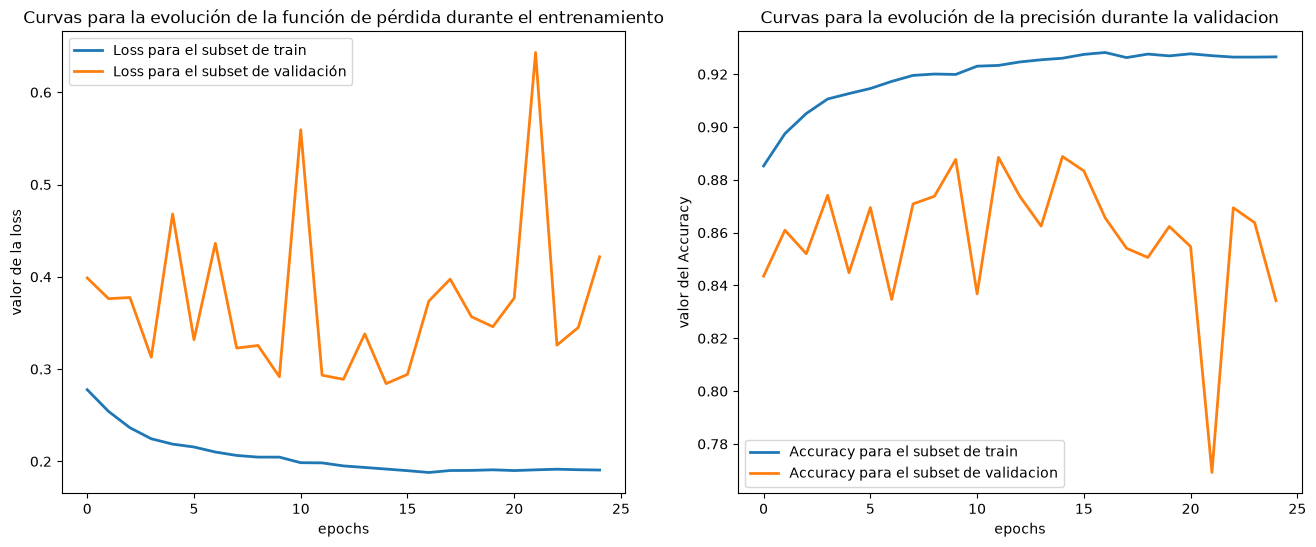

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curva de la función de pérdida
axes[0].plot(history_pruebas_gpu.history['loss'], label='Loss para el subset de train', lw=2)
axes[0].plot(history_pruebas_gpu.history['val_loss'], label='Loss para el subset de validación', lw=2)
axes[0].set_title('Curvas para la evolución de la función de pérdida durante el entrenamiento')
axes[0].set_xlabel('epochs')
axes[0].set_ylabel('valor de la loss')
axes[0].legend()

# Curva de precisión
axes[1].plot(history_pruebas_gpu.history['accuracy'], label='Accuracy para el subset de train', lw=2)
axes[1].plot(history_pruebas_gpu.history['val_accuracy'], label='Accuracy para el subset de validacion', lw=2)
axes[1].set_title('Curvas para la evolución de la precisión durante la validacion')
axes[1].set_xlabel('epochs')
axes[1].set_ylabel('valor del Accuracy')
axes[1].legend()

In [13]:
cnn = tf.keras.models.load_model('mejor_cnn1_gpu.h5')

In [34]:
dataset_test_batch = dataset_test_processed.batch(200)
x_test = []
y_test = []
for img, label in dataset_test_batch:
    x_test.append(img.numpy())
    y_test.append(label.numpy())

In [35]:
X_test_concat = np.concatenate(x_test, axis=0)
y_test_concat = np.concatenate(y_test, axis=0)

In [16]:
y_test_pred = cnn.predict(X_test_concat)

1024/1024 [==============================] - 7s 7ms/step


In [17]:
threshold_to_tumor = 0.5
y_test_class_pred = (y_test_pred >= 0.5).astype("int32")

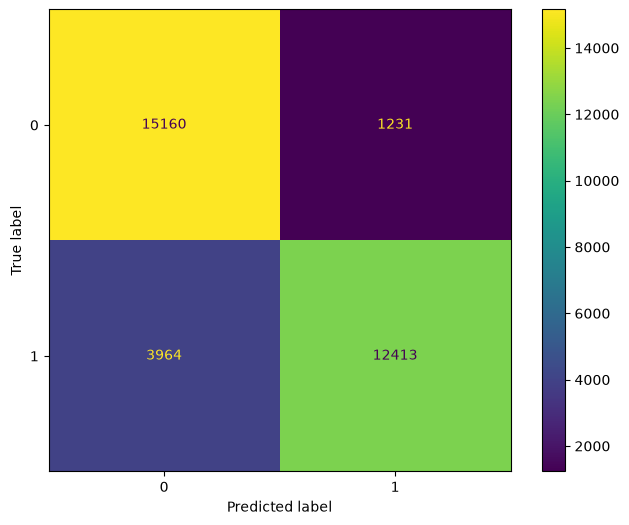

In [18]:
matriz_confusion = confusion_matrix(y_test_concat, y_test_class_pred)

fig, ax = plt.subplots(figsize=(8, 6))
cm_display = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion)
cm_display.plot(ax=ax, values_format='d')

In [19]:
print(classification_report(y_test_concat, y_test_class_pred))

              precision    recall  f1-score   support

           0       0.79      0.92      0.85     16391
           1       0.91      0.76      0.83     16377

    accuracy                           0.84     32768
   macro avg       0.85      0.84      0.84     32768
weighted avg       0.85      0.84      0.84     32768



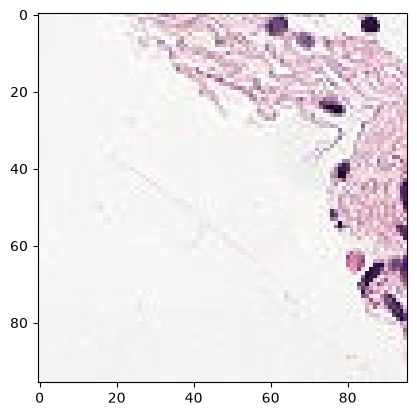

In [36]:
plt.imshow(X_test_concat[0])

In [37]:
y_test_class_pred[0]

array([0], dtype=int32)

In [38]:
y_test_concat[0]

0

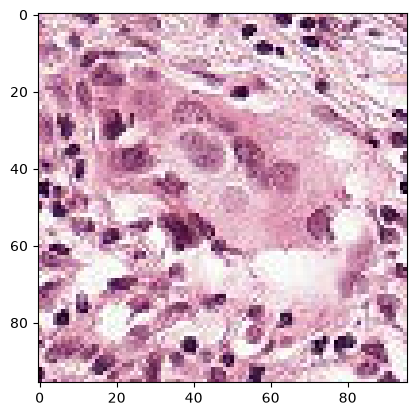

In [39]:
plt.imshow(X_test_concat[1])

In [40]:
y_test_concat[1]

1

In [41]:
y_test_class_pred[1]

array([1], dtype=int32)

# CNN_2

In [27]:
# Prueba 2
# Vamos a añadir un callback que cuando de salto reduzca el learning rate
# Vamos a aumentar el dropout a 0.3

cnn2 = models.Sequential([
    layers.Input(shape=(n_rows_per_img,n_columns_per_img,n_channels_per_img)),
    normalization_layer,

    layers.Conv2D(35, (2,2), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Conv2D(32, (3,3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.1),

    layers.Conv2D(65, (3,3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.3),

    layers.Conv2D(65, (3,3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3,3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.3),
    
    layers.Conv2D(128, (3,3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.3),

    #Red neuronal para la clasificación
    layers.Flatten(),
    layers.Dense(512, activation="relu",kernel_initializer="random_normal"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

In [28]:
reduce_lr_callback = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

## Entrenamiento

In [ ]:
mom_optimizer = optimizers.SGD(momentum=0.8)

batch_size_cnn1 = 128

dataset_train_batch = (
    dataset_train_processed
    .shuffle(5000, seed=seed, reshuffle_each_iteration=True)
    .batch(batch_size_cnn1)
    .prefetch(tf.data.AUTOTUNE)
)

dataset_val_batch = (
    dataset_val_processed
    .batch(batch_size_cnn1)
    .prefetch(tf.data.AUTOTUNE)
)

with tf.device(training_device):
    cnn2.compile(
        optimizer = mom_optimizer,
        loss = "binary_crossentropy",
        metrics = ["accuracy",
                tf.keras.metrics.AUC(name="auc"),
                tf.keras.metrics.Precision(name="precision"),
                tf.keras.metrics.Recall(name="recall")
                ]
    )

    list_callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(filepath="mejor_cnn2.h5", monitor="val_auc", mode="max", save_best_only=True),
        reduce_lr_callback
    ]

    # Entrenamos la red
    history_pruebas2 = cnn2.fit(dataset_train_batch,
                            validation_data=dataset_val_batch,
                            epochs=100,
                            batch_size=128,
                            callbacks=list_callbacks)

Epoch 1/100


2026-06-23 01:58:14.365307: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node SGD/AssignVariableOp.


2048/2048 [==============================] - 258s 126ms/step - loss: 0.3640 - accuracy: 0.8445 - auc: 0.9197 - precision: 0.8527 - recall: 0.8329 - val_loss: 0.5730 - val_accuracy: 0.7820 - val_auc: 0.9105 - val_precision: 0.9084 - val_recall: 0.6267 - lr: 0.0100
Epoch 2/100


/Users/montsesacie/practicas/TFM/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


2048/2048 [==============================] - 290s 142ms/step - loss: 0.2758 - accuracy: 0.8870 - auc: 0.9539 - precision: 0.8923 - recall: 0.8804 - val_loss: 0.3844 - val_accuracy: 0.8419 - val_auc: 0.9324 - val_precision: 0.8880 - val_recall: 0.7820 - lr: 0.0100
Epoch 3/100
2048/2048 [==============================] - 274s 134ms/step - loss: 0.2379 - accuracy: 0.9046 - auc: 0.9655 - precision: 0.9099 - recall: 0.8983 - val_loss: 0.4175 - val_accuracy: 0.8410 - val_auc: 0.9454 - val_precision: 0.9350 - val_recall: 0.7327 - lr: 0.0100
Epoch 4/100
2048/2048 [==============================] - 263s 128ms/step - loss: 0.2171 - accuracy: 0.9146 - auc: 0.9712 - precision: 0.9196 - recall: 0.9088 - val_loss: 0.4480 - val_accuracy: 0.8069 - val_auc: 0.9085 - val_precision: 0.8797 - val_recall: 0.7106 - lr: 0.0100
Epoch 5/100
2048/2048 [==============================] - ETA: 0s - loss: 0.2053 - accuracy: 0.9193 - auc: 0.9741 - precision: 0.9243 - recall: 0.9133
Epoch 5: ReduceLROnPlateau reducin

In [68]:
cnn2.save("mejor_CNN2_segun_val_loss.h5")

/Users/montsesacie/practicas/TFM/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluacion

In [ ]:
CNN2_1 = tf.keras.models.load_model('mejor_cnn2.h5')

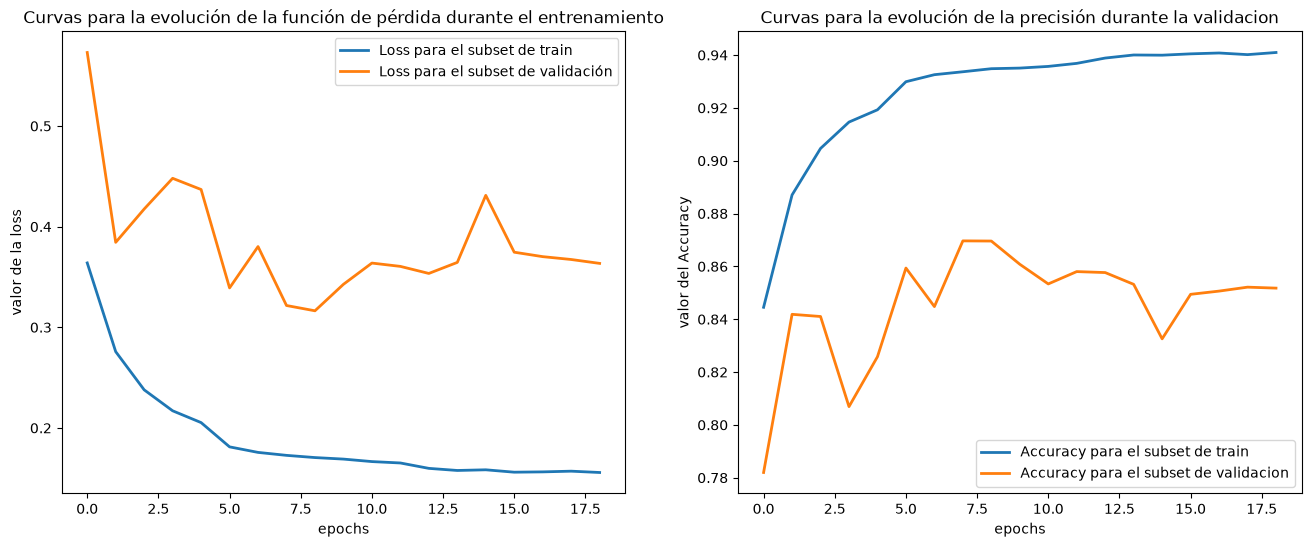

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curva de la función de pérdida
axes[0].plot(history_pruebas2.history['loss'], label='Loss para el subset de train', lw=2)
axes[0].plot(history_pruebas2.history['val_loss'], label='Loss para el subset de validación', lw=2)
axes[0].set_title('Curvas para la evolución de la función de pérdida durante el entrenamiento')
axes[0].set_xlabel('epochs')
axes[0].set_ylabel('valor de la loss')
axes[0].legend()

# Curva de precisión
axes[1].plot(history_pruebas2.history['accuracy'], label='Accuracy para el subset de train', lw=2)
axes[1].plot(history_pruebas2.history['val_accuracy'], label='Accuracy para el subset de validacion', lw=2)
axes[1].set_title('Curvas para la evolución de la precisión durante la validacion')
axes[1].set_xlabel('epochs')
axes[1].set_ylabel('valor del Accuracy')
axes[1].legend()

In [77]:
y_test_pred = CNN2_1.predict(X_test_concat)

1024/1024 [==============================] - 15s 14ms/step


In [78]:
threshold_to_tumor = 0.5
y_test_class_pred = (y_test_pred >= 0.5).astype("int32")

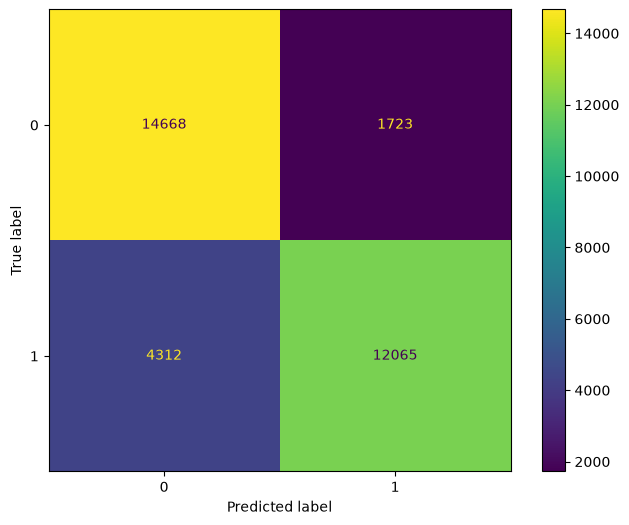

In [73]:
matriz_confusion = confusion_matrix(y_test_concat, y_test_class_pred)

fig, ax = plt.subplots(figsize=(8, 6))
cm_display = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion)
cm_display.plot(ax=ax, values_format='d')

In [74]:
print(classification_report(y_test_concat, y_test_class_pred))

              precision    recall  f1-score   support

           0       0.77      0.89      0.83     16391
           1       0.88      0.74      0.80     16377

    accuracy                           0.82     32768
   macro avg       0.82      0.82      0.81     32768
weighted avg       0.82      0.82      0.81     32768



# CNN_3 - Data Augmentation


## Data Augmentation

In [5]:
data_agumentation_block = tf.keras.Sequential([
    layers.RandomRotation(0.25),
    layers.RandomFlip("horizontal"),
    ])

In [6]:
subset_to_Augment = 50000
idx = np.random.choice(len(X_train["x"]), subset_to_Augment, replace=False)
idx = np.sort(idx)

X_to_aug = X_train["x"][idx]
y_to_aug = y_train["y"][idx]

In [10]:
X_subset_tf = tf.cast(X_to_aug, tf.float32) / 255.0
X_subset_aug = data_agumentation_block(X_subset_tf, training=True)
X_subset_aug = tf.clip_by_value(X_subset_aug, 0.0, 1.0)
X_subset_aug = tf.cast(X_subset_aug * 255.0, tf.uint8).numpy()

In [ ]:
X_train_final = np.concatenate([X_train["x"], X_subset_aug], axis=0)
y_train_final = np.concatenate([y_train["y"], y_to_aug], axis=0)

In [22]:
X_train_final

array([[[[226, 209, 225],
         [224, 210, 225],
         [223, 211, 223],
         ...,
         [218, 178, 230],
         [214, 182, 221],
         [188, 161, 192]],

        [[223, 209, 224],
         [222, 210, 224],
         [221, 211, 222],
         ...,
         [127,  87, 150],
         [159, 126, 181],
         [204, 176, 225]],

        [[222, 210, 224],
         [221, 210, 224],
         [219, 211, 222],
         ...,
         [ 77,  38, 117],
         [ 42,   8,  84],
         [137, 107, 179]],

        ...,

        [[123,  81, 165],
         [128,  90, 173],
         [126,  91, 173],
         ...,
         [203, 135, 210],
         [226, 155, 223],
         [202, 130, 194]],

        [[ 90,  52, 139],
         [ 90,  56, 142],
         [ 79,  45, 131],
         ...,
         [216, 152, 230],
         [179, 113, 185],
         [217, 152, 220]],

        [[ 85,  51, 138],
         [101,  68, 155],
         [ 91,  59, 144],
         ...,
         [200, 136, 220],
        

In [23]:
y_train_final

array([[[[0]]],


       [[[1]]],


       [[[1]]],


       ...,


       [[[1]]],


       [[[1]]],


       [[[1]]]], dtype=uint8)

In [ ]:
dataset_train = tf.data.Dataset.from_tensor_slices((X_train_final, y_train_final))
dataset_train_processed = dataset_train.map(image_preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
mean_by_RGB, var_by_RGB, std_RGB = get_statistics(dataset_train_processed)
n_rows_per_img = X_train_final.shape[1]
n_columns_per_img = X_train_final.shape[2]
n_channels_per_img = X_train_final.shape[3]

In [25]:
normalization_layer = layers.Normalization(
    mean=mean_by_RGB,
    variance=var_by_RGB,
    input_shape=(n_rows_per_img, n_columns_per_img, n_channels_per_img)
)

In [29]:
cnn4 = models.Sequential([
    layers.Input(shape=(n_rows_per_img,n_columns_per_img,n_channels_per_img)),
    normalization_layer,

    layers.Conv2D(35, (2,2), activation="relu", padding='same'),
    layers.BatchNormalization(),

    layers.Conv2D(32, (3,3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.1),

    layers.Conv2D(65, (3,3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),

    layers.Conv2D(65, (3,3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),

    layers.Conv2D(128, (3,3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),
    
    layers.Conv2D(128, (3,3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    #Red neuronal para la clasificación
    layers.Flatten(),
    layers.Dense(512, activation="relu",kernel_initializer="random_normal"),
    layers.BatchNormalization(),
    layers.Dropout(0.35),
    layers.Dense(1, activation="sigmoid")
])

## Entrenamiento

In [ ]:
mom_optimizer = tf.keras.optimizers.legacy.SGD(momentum=0.8)

batch_size_cnn1 = 128

dataset_train_batch = (
    dataset_train_processed
    .shuffle(5000, seed=seed, reshuffle_each_iteration=True)
    .batch(batch_size_cnn1)
    .prefetch(tf.data.AUTOTUNE)
)

dataset_val_batch = (
    dataset_val_processed
    .batch(batch_size_cnn1)
    .prefetch(tf.data.AUTOTUNE)
)

cnn4.compile(
    optimizer = mom_optimizer,
    loss = "binary_crossentropy",
    metrics = ["accuracy",
               tf.keras.metrics.AUC(name="auc"),
               tf.keras.metrics.Precision(name="precision"),
               tf.keras.metrics.Recall(name="recall")
               ]
)

list_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(filepath="mejor_cnn3.h5", monitor="val_auc", mode="max", save_best_only=True),
    reduce_lr_callback
]

# Entrenamos la red
history_pruebas4 = cnn4.fit(dataset_train_batch,
                        validation_data=dataset_val_batch,
                        epochs=100,
                        callbacks=list_callbacks)

Epoch 1/100
2439/2439 [==============================] - 297s 122ms/step - loss: 0.3451 - accuracy: 0.8529 - auc: 0.9274 - precision: 0.8595 - recall: 0.8435 - val_loss: 0.5004 - val_accuracy: 0.7820 - val_auc: 0.9017 - val_precision: 0.8627 - val_recall: 0.6702 - lr: 0.0100
Epoch 2/100
2439/2439 [==============================] - 325s 133ms/step - loss: 0.2483 - accuracy: 0.9001 - auc: 0.9624 - precision: 0.9048 - recall: 0.8944 - val_loss: 0.6133 - val_accuracy: 0.7535 - val_auc: 0.9162 - val_precision: 0.9255 - val_recall: 0.5509 - lr: 0.0100
Epoch 3/100
2439/2439 [==============================] - 327s 134ms/step - loss: 0.2151 - accuracy: 0.9153 - auc: 0.9716 - precision: 0.9206 - recall: 0.9089 - val_loss: 0.5359 - val_accuracy: 0.8029 - val_auc: 0.9230 - val_precision: 0.9419 - val_recall: 0.6452 - lr: 0.0100
Epoch 4/100
2439/2439 [==============================] - 317s 130ms/step - loss: 0.1989 - accuracy: 0.9227 - auc: 0.9755 - precision: 0.9281 - recall: 0.9165 - val_loss: 0.

## Evaluacion

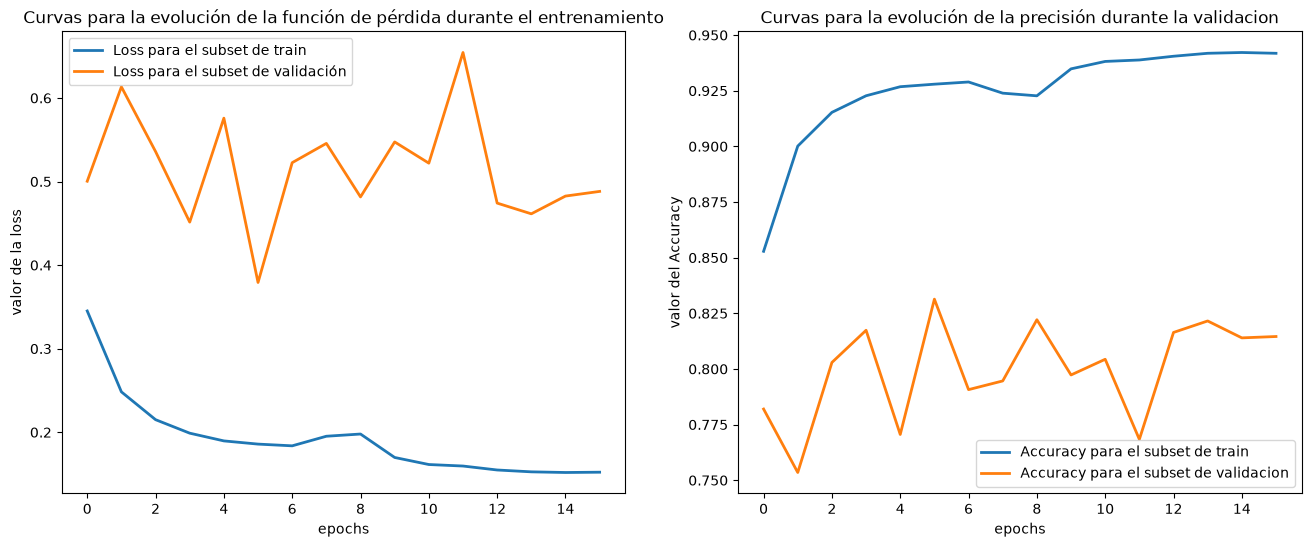

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curva de la función de pérdida
axes[0].plot(history_pruebas4.history['loss'], label='Loss para el subset de train', lw=2)
axes[0].plot(history_pruebas4.history['val_loss'], label='Loss para el subset de validación', lw=2)
axes[0].set_title('Curvas para la evolución de la función de pérdida durante el entrenamiento')
axes[0].set_xlabel('epochs')
axes[0].set_ylabel('valor de la loss')
axes[0].legend()

# Curva de precisión
axes[1].plot(history_pruebas4.history['accuracy'], label='Accuracy para el subset de train', lw=2)
axes[1].plot(history_pruebas4.history['val_accuracy'], label='Accuracy para el subset de validacion', lw=2)
axes[1].set_title('Curvas para la evolución de la precisión durante la validacion')
axes[1].set_xlabel('epochs')
axes[1].set_ylabel('valor del Accuracy')
axes[1].legend()

In [35]:
y_test_pred = cnn4.predict(X_test_concat)

1024/1024 [==============================] - 13s 13ms/step


In [40]:
threshold_to_tumor = 0.5
y_test_class_pred = (y_test_pred >= 0.5).astype("int32")

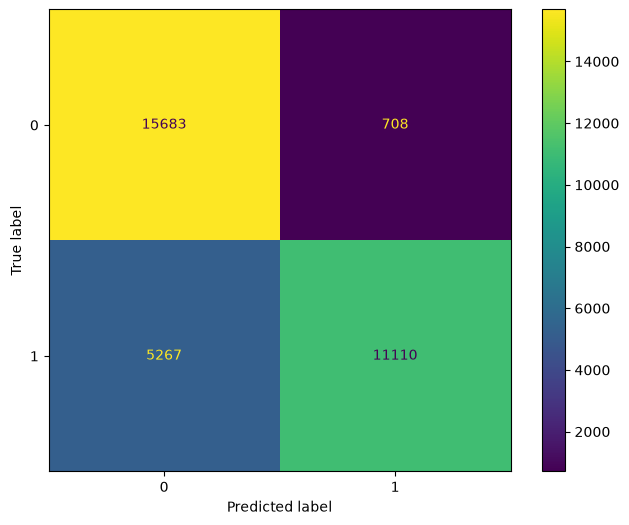

In [38]:
matriz_confusion = confusion_matrix(y_test_concat, y_test_class_pred)

fig, ax = plt.subplots(figsize=(8, 6))
cm_display = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion)
cm_display.plot(ax=ax, values_format='d')

In [39]:
print(classification_report(y_test_concat, y_test_class_pred))

              precision    recall  f1-score   support

           0       0.75      0.96      0.84     16391
           1       0.94      0.68      0.79     16377

    accuracy                           0.82     32768
   macro avg       0.84      0.82      0.81     32768
weighted avg       0.84      0.82      0.81     32768



# CNN_4 con Data Augmentation
Reducir neuronas de la capa densa y aumentar un poco más el Data Augmentation

In [15]:
data_agumentation_block = tf.keras.Sequential([
    layers.RandomRotation(0.25),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomBrightness(0.2)
    ])

In [16]:
subset_to_Augment = 50000
idx = np.random.choice(len(X_train["x"]), subset_to_Augment, replace=False)
idx = np.sort(idx)

X_to_aug = X_train["x"][idx]
y_to_aug = y_train["y"][idx]

In [17]:
X_subset_tf = tf.cast(X_to_aug, tf.float32) / 255.0
X_subset_aug = data_agumentation_block(X_subset_tf, training=True)
X_subset_aug = tf.clip_by_value(X_subset_aug, 0.0, 1.0)
X_subset_aug = tf.cast(X_subset_aug * 255.0, tf.uint8).numpy()

In [18]:
X_train_final = np.concatenate([X_train["x"], X_subset_aug], axis=0)
y_train_final = np.concatenate([y_train["y"], y_to_aug], axis=0)

In [21]:
dataset_train = tf.data.Dataset.from_tensor_slices((X_train_final, y_train_final))
dataset_train_processed = dataset_train.map(image_preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
mean_by_RGB, var_by_RGB, std_RGB = get_statistics(dataset_train_processed)
n_rows_per_img = X_train_final.shape[1]
n_columns_per_img = X_train_final.shape[2]
n_channels_per_img = X_train_final.shape[3]

In [22]:
normalization_layer = layers.Normalization(
    mean=mean_by_RGB,
    variance=var_by_RGB,
    input_shape=(n_rows_per_img, n_columns_per_img, n_channels_per_img)
)

In [23]:
cnn5 = models.Sequential([
    layers.Input(shape=(n_rows_per_img,n_columns_per_img,n_channels_per_img)),
    normalization_layer,

    layers.Conv2D(35, (2,2), activation="relu", padding='same'),
    layers.BatchNormalization(),

    layers.Conv2D(32, (3,3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.1),

    layers.Conv2D(65, (3,3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),

    layers.Conv2D(128, (3,3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),
    

    #Red neuronal para la clasificación
    layers.Flatten(),
    layers.Dense(256, activation="relu",kernel_initializer="random_normal"),
    layers.BatchNormalization(),
    layers.Dropout(0.35),
    layers.Dense(1, activation="sigmoid")
])

## Entrenamiento

In [ ]:
mom_optimizer = tf.keras.optimizers.legacy.SGD(momentum=0.8) #

batch_size_cnn = 512

dataset_train_batch = (
    dataset_train_processed
    .shuffle(5000, seed=seed, reshuffle_each_iteration=True)
    .batch(batch_size_cnn)
    .prefetch(tf.data.AUTOTUNE)
)

dataset_val_batch = (
    dataset_val_processed
    .batch(batch_size_cnn)
    .prefetch(tf.data.AUTOTUNE)
)

cnn5.compile(
    optimizer = mom_optimizer,
    loss = "binary_crossentropy",
    metrics = ["accuracy",
               tf.keras.metrics.AUC(name="auc"),
               tf.keras.metrics.Precision(name="precision"),
               tf.keras.metrics.Recall(name="recall")
               ]
)

list_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(filepath="mejor_cnn4.h5", monitor="val_auc", mode="max", save_best_only=True),
    reduce_lr_callback
]

# Entrenamos la red
history_pruebas5 = cnn5.fit(dataset_train_batch,
                        validation_data=dataset_val_batch,
                        epochs=100,
                        callbacks=list_callbacks)

Epoch 1/100
610/610 [==============================] - 289s 473ms/step - loss: 0.4686 - accuracy: 0.7628 - auc: 0.8576 - precision: 0.7564 - recall: 0.7751 - val_loss: 0.6223 - val_accuracy: 0.5711 - val_auc: 0.8546 - val_precision: 0.5383 - val_recall: 0.9944 - lr: 0.0100
Epoch 2/100


/Users/montsesacie/practicas/TFM/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


610/610 [==============================] - 304s 499ms/step - loss: 0.4143 - accuracy: 0.7905 - auc: 0.8895 - precision: 0.7806 - recall: 0.8081 - val_loss: 0.5477 - val_accuracy: 0.6990 - val_auc: 0.8191 - val_precision: 0.6604 - val_recall: 0.8184 - lr: 0.0100
Epoch 3/100
610/610 [==============================] - 558s 915ms/step - loss: 0.3937 - accuracy: 0.8005 - auc: 0.9002 - precision: 0.7895 - recall: 0.8194 - val_loss: 0.5714 - val_accuracy: 0.6581 - val_auc: 0.8230 - val_precision: 0.6042 - val_recall: 0.9147 - lr: 0.0100
Epoch 4/100
610/610 [==============================] - 324s 531ms/step - loss: 0.3773 - accuracy: 0.8084 - auc: 0.9085 - precision: 0.7977 - recall: 0.8264 - val_loss: 0.5374 - val_accuracy: 0.7038 - val_auc: 0.8255 - val_precision: 0.6688 - val_recall: 0.8063 - lr: 0.0100
Epoch 5/100
610/610 [==============================] - 325s 532ms/step - loss: 0.3683 - accuracy: 0.8130 - auc: 0.9129 - precision: 0.8019 - recall: 0.8313 - val_loss: 0.5756 - val_accuracy:

## Evaluacion

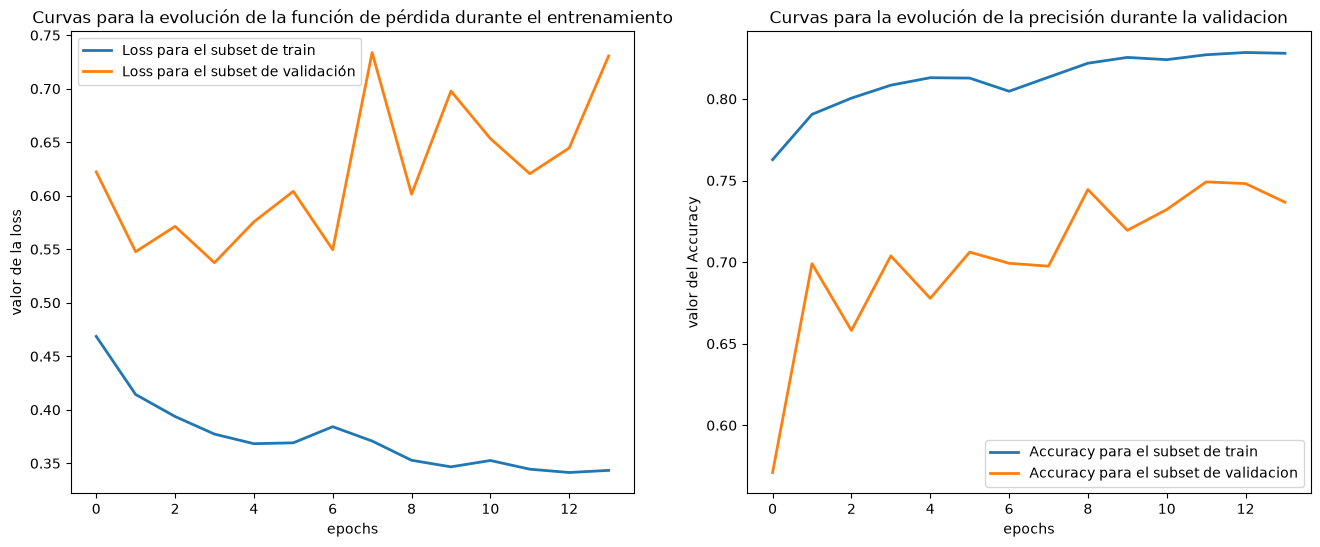

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curva de la función de pérdida
axes[0].plot(history_pruebas5.history['loss'], label='Loss para el subset de train', lw=2)
axes[0].plot(history_pruebas5.history['val_loss'], label='Loss para el subset de validación', lw=2)
axes[0].set_title('Curvas para la evolución de la función de pérdida durante el entrenamiento')
axes[0].set_xlabel('epochs')
axes[0].set_ylabel('valor de la loss')
axes[0].legend()

# Curva de precisión
axes[1].plot(history_pruebas5.history['accuracy'], label='Accuracy para el subset de train', lw=2)
axes[1].plot(history_pruebas5.history['val_accuracy'], label='Accuracy para el subset de validacion', lw=2)
axes[1].set_title('Curvas para la evolución de la precisión durante la validacion')
axes[1].set_xlabel('epochs')
axes[1].set_ylabel('valor del Accuracy')
axes[1].legend()

In [32]:
y_test_pred = cnn5.predict(X_test_concat)

1024/1024 [==============================] - 14s 13ms/step


In [33]:
threshold_to_tumor = 0.5
y_test_class_pred = (y_test_pred >= 0.5).astype("int32")

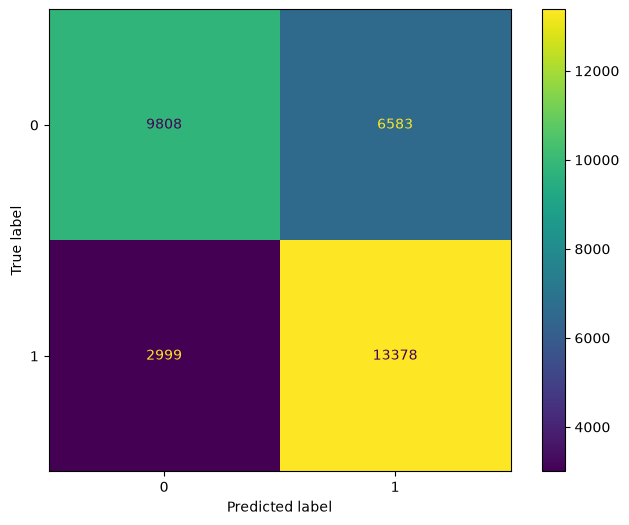

In [34]:
matriz_confusion = confusion_matrix(y_test_concat, y_test_class_pred)

fig, ax = plt.subplots(figsize=(8, 6))
cm_display = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion)
cm_display.plot(ax=ax, values_format='d')

In [35]:
print(classification_report(y_test_concat, y_test_class_pred))

              precision    recall  f1-score   support

           0       0.77      0.60      0.67     16391
           1       0.67      0.82      0.74     16377

    accuracy                           0.71     32768
   macro avg       0.72      0.71      0.70     32768
weighted avg       0.72      0.71      0.70     32768

